In [1]:
import torch 
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
from skimage.transform import resize

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
audio_paths = []
labels = []

data_dir = "data"

for label in os.listdir(data_dir):
    folder = os.path.join(data_dir, label)

    if os.path.isdir(folder):
        for audio in os.listdir(folder):
            audio_paths.append(os.path.join(folder, audio))
            labels.append(label)

data = pd.DataFrame({ "audio_path": audio_paths, "label": labels })

In [4]:
le = LabelEncoder()
data["label_encoded"] = le.fit_transform(data["label"])

In [5]:
train = data.sample(frac=0.7, random_state=42)
remaining = data.drop(train.index)

val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

In [6]:
import torchaudio

mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=22050, n_fft=1024, hop_length=512, n_mels=128)

In [7]:
import torch
import torchaudio
from torch.utils.data import Dataset

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=22050,
    n_mels=128
)

class AudioDataset(Dataset):
    def __init__(self, dataframe, max_len=130, clip_duration=3, train=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.max_len = max_len
        self.train = train
        self.target_sr = 22050
        self.clip_len = self.target_sr * clip_duration

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        audio_path = self.dataframe.loc[index, "audio_path"]
        label = self.dataframe.loc[index, "label_encoded"]

        waveform, sr = torchaudio.load(audio_path)

        # convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # resample
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.target_sr)
            waveform = resampler(waveform)

        # crop or pad waveform to fixed 3 seconds
        if waveform.shape[1] > self.clip_len:
            if self.train:
                start = torch.randint(0, waveform.shape[1] - self.clip_len + 1, (1,)).item()
            else:
                start = (waveform.shape[1] - self.clip_len) // 2
            waveform = waveform[:, start:start + self.clip_len]
        else:
            pad_amount = self.clip_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))

        # mel spectrogram
        spectrogram = mel_transform(waveform)

        # log mel spectrogram
        spectrogram = torch.log(spectrogram + 1e-9)

        # pad or truncate spectrogram time dimension
        if spectrogram.shape[2] < self.max_len:
            pad_amount = self.max_len - spectrogram.shape[2]
            spectrogram = torch.nn.functional.pad(spectrogram, (0, pad_amount))
        else:
            spectrogram = spectrogram[:, :, :self.max_len]

        # normalize
        spectrogram = (spectrogram - spectrogram.mean()) / (spectrogram.std() + 1e-9)

        return spectrogram, torch.tensor(label, dtype=torch.long)

C:\Users\Administrator\anaconda3\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [8]:
train_dataset = AudioDataset(train, max_len=130)
val_dataset = AudioDataset(val, max_len=130)
test_dataset = AudioDataset(test, max_len=130)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
class AudioClassificationModel(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4,4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
num_classes = len(le.classes_)
model = AudioClassificationModel(num_classes=num_classes).to(device)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [12]:
epochs = 30

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in range(epochs):
    train_loss = 0.0
    train_correct = 0

    val_loss = 0.0
    val_correct = 0

    # training
    model.train()
    for spectrograms, labels in train_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()

    # validation
    model.eval()
    with torch.no_grad():
        for spectrograms, labels in val_loader:
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)

            outputs = model(spectrograms)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    train_loss_plot.append(train_loss)
    val_loss_plot.append(val_loss)
    train_acc_plot.append(train_acc)
    val_acc_plot.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch 1/30 | Train Loss: 2.3013 | Train Acc: 0.1029 | Val Loss: 2.2964 | Val Acc: 0.0867
Epoch 2/30 | Train Loss: 2.2534 | Train Acc: 0.1486 | Val Loss: 2.1660 | Val Acc: 0.3467
Epoch 3/30 | Train Loss: 2.0939 | Train Acc: 0.2414 | Val Loss: 1.9939 | Val Acc: 0.3200
Epoch 4/30 | Train Loss: 1.9751 | Train Acc: 0.2657 | Val Loss: 1.8331 | Val Acc: 0.3933
Epoch 5/30 | Train Loss: 1.9031 | Train Acc: 0.2814 | Val Loss: 1.8448 | Val Acc: 0.3067
Epoch 6/30 | Train Loss: 1.8309 | Train Acc: 0.3129 | Val Loss: 1.7391 | Val Acc: 0.3867
Epoch 7/30 | Train Loss: 1.8212 | Train Acc: 0.3229 | Val Loss: 1.7199 | Val Acc: 0.3867
Epoch 8/30 | Train Loss: 1.7416 | Train Acc: 0.3386 | Val Loss: 1.6955 | Val Acc: 0.4133
Epoch 9/30 | Train Loss: 1.7374 | Train Acc: 0.3686 | Val Loss: 1.6699 | Val Acc: 0.4067
Epoch 10/30 | Train Loss: 1.7219 | Train Acc: 0.3500 | Val Loss: 1.6819 | Val Acc: 0.4133
Epoch 11/30 | Train Loss: 1.6870 | Train Acc: 0.3786 | Val Loss: 1.6076 | Val Acc: 0.4200
Epoch 12/30 | Train

In [13]:
test_loss = 0.0
test_correct = 0

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for spectrograms, labels in test_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_acc = test_correct / len(test_loader.dataset)

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 1.3454 | Test Acc: 0.4933


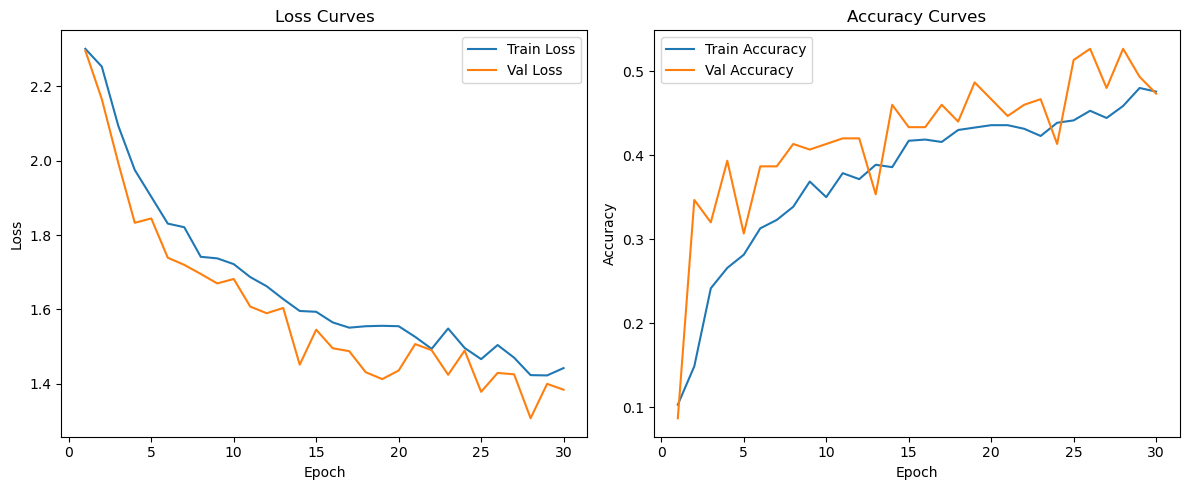

In [14]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_loss_plot) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_plot, label="Train Loss")
plt.plot(epochs_range, val_loss_plot, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_plot, label="Train Accuracy")
plt.plot(epochs_range, val_acc_plot, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

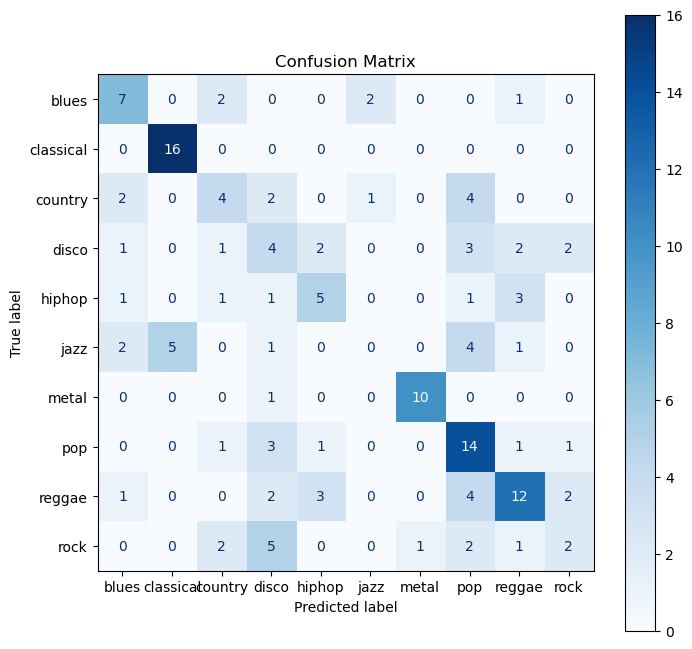

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title("Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.50      0.58      0.54        12
   classical       0.76      1.00      0.86        16
     country       0.36      0.31      0.33        13
       disco       0.21      0.27      0.24        15
      hiphop       0.45      0.42      0.43        12
        jazz       0.00      0.00      0.00        13
       metal       0.91      0.91      0.91        11
         pop       0.44      0.67      0.53        21
      reggae       0.57      0.50      0.53        24
        rock       0.29      0.15      0.20        13

    accuracy                           0.49       150
   macro avg       0.45      0.48      0.46       150
weighted avg       0.45      0.49      0.47       150



In [17]:
import os
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/audio_classifier.pth")
print("Model save success")

Model save success
